# 📌 Tugas 8 - Praktikum Data Science

> Copy template ini lalu kerjakan menggunakan template ini.

> Referensi untuk mengerjakan tugas :
> - https://colab.research.google.com/drive/1cCozod_L1um-5E4YDhD2RLoNXRNoylq9?usp=sharing
> - https://colab.research.google.com/drive/1_5ehUVxBed28qwAPLcR0C9aaYoaPiNZ3?usp=sharing
> - https://colab.research.google.com/drive/15KuXtQRyhSbMoimVmi0zjE06e9EwKT6s?usp=sharing
> - https://colab.research.google.com/drive/10BuLMoi9megpSFmn9AcYSXt8z6xCo3hT?usp=sharing

---

Tugas ini bertujuan untuk membantu kalian memahami beberapa teknik Data Science menggunakan data asli.
Silakan download dataset di : https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

- Nama lengkap : Muhammad Zaenal Abidin Abdurrahman
- Program : AI Development

Setiap langkah, setiap cell terdapat 'insight' hasil analisis dari kode yang dijalankan. Berikan insight sesuai dengan cell yang dijalankan.

## Notice

There will be some code cells where the Markdown is placed directly below them—a location not designated by the assignment for placing Markdown. The reason I’ve placed the Markdown outside the designated area is to make it easier for me to understand what’s happening in each cell in greater detail.

This way, I can understand the material and absorb the knowledge in this IPython Notebook more easily. The explanations of what is happening are a combination of what I’ve learned from the internet, source material given at the very beginning and AI (here I’m using Gemini Pro for explaining to me the concept or why do we need to do that and this, what happened, how to read the code and output from it and etc etc).

**0. Import module yang diperlukan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # kebiasaan saja
import warnings
warnings.filterwarnings('ignore') # not a best approach, but i think it's okay

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas, atau teknik lainnya seperti describe()



In [ ]:
df = pd.read_csv('/content/Housing.csv')

In [ ]:
print("=== 1. Dataset Shape ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("=== 2. Top 5 Rows (head) ===")
display(df.head())

print("\n=== 3. Bottom 5 Rows (tail) ===")
display(df.tail())

print("\n=== 4. Dataset Information (info) ===")
df.info()

print("\n=== 5. Descriptive Statistics ===")
display(df.describe().round(2))

=== 1. Dataset Shape ===
Total Rows: 545
Total Columns: 13

=== 2. Top 5 Rows (head) ===


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



=== 3. Bottom 5 Rows (tail) ===


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished



=== 4. Dataset Information (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

=== 5. Descriptive Statistics ===


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


**Insight Step 1: Initial Data Inspection**

* **Dataset Dimensions:** The housing dataset consists of 545 records (houses) and 13 variables.

* **Data Type Bipartition:** The data is structurally split between numerical features (6 columns of type `int64`, including the target variable `price`) and categorical text features (7 columns of type `object`, such as `mainroad` and `furnishingstatus`).

* **Machine Learning Readiness:** The presence of `object` datatypes indicates that the dataset is not yet ready for predictive modeling or correlation analysis. We must execute Feature Transformation (Categorical Encoding) to convert these text values into numerical arrays before applying mathematical models.

* **Value Distribution:** Descriptive statistics reveal significant variance, particularly in the `price` target (ranging from 1.75M to 13.3M) and `area` (1,650 to 16,200 sq ft), suggesting the potential presence of luxury property outliers that may require normalization during the modeling phase.

**2. Cek Missing values dan duplicate pada data**
> Cek apakah ada missing values / duplicate pada data, jika ada perbaiki, jika tidak ada, berikan insight/penjelasan.

In [ ]:
print("=== Missing Values Audit ===") # From cell above, i already know that there will be no missing_values
missing_values = df.isna().sum()
display(missing_values)

=== Missing Values Audit ===


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
print("=== Duplicates Audit ===")

duplicate_count = df.duplicated().sum()

print(f"Total exact duplicate rows found: {duplicate_count}")

# If there are duplicates, let's see what they look like
if duplicate_count > 0:
    print("\nDisplaying the duplicated rows:")
    display(df[df.duplicated(keep=False)].sort_values(by='price'))
else:
    print("Dataset is clean from duplicates! No action needed.")

=== Duplicates Audit ===
Total exact duplicate rows found: 0
Dataset is clean from duplicates! No action needed.


Insight :

The data quality is already strong. I found no missing values in any column and no duplicated rows in the dataset. This means the dataset is complete and does not require major cleaning before analysis. Even so, it is still good practice to verify these conditions explicitly before moving to the next step.


**3. Hapus data jika ada duplicate dan isi missing values jika ada**

Even though the dataset is already clean, I still write a robust cleaning procedure so the notebook remains reusable if a similar dataset with missing values or duplicates is used in the future.

In [ ]:
# Dropping rows causes critical information loss (as far as i know, it is absolutely not the best practise and not recommended at all to remove or drop a column/data. Data is really important). Instead, we dynamically fill (impute) missing data.

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numerical gaps with the Median (robust against outliers)
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical gaps with the Mode (the most frequent category)
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Status: Dynamic Imputation Pipeline executed.")

Status: Dynamic Imputation Pipeline executed.


In [ ]:
df.drop_duplicates(inplace=True)

print(f"Status: Duplicate check executed. Final dataset shape remains {df.shape}.")

Status: Duplicate check executed. Final dataset shape remains (545, 13).


**Insight Step 3: Robust Data Imputation Pipeline**

* **Preserving Data Integrity:** In real-world scenarios, aggressively dropping rows with missing values results in critical information loss. To demonstrate enterprise-level best practices, a dynamic imputation pipeline was engineered instead of a standard drop.

* **Mathematical Imputation:** The algorithm dynamically identifies column types; it fills numerical gaps using the statistical median (to resist distortion from luxury outliers) and categorical gaps using the mode (highest frequency).

* **Pipeline Resilience:** While the current dataset is already immaculate, this pipeline ensures the code architecture remains completely unbroken and functional even if corrupted or incomplete data is injected in the future. Exact duplicates, which introduce artificial frequency bias, are systematically dropped.

**4. Transformasi format**

> Cek dataset, apakah ada data yang bisa ditransformasi? (cth : yes or no menjadi 1 dan 0)

Several columns use yes and no values. I transform them into 1 and 0 so they are easier to analyze numerically.

In [ ]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

furnishing_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishingstatus'] = df['furnishingstatus'].map(furnishing_map)

print("=== Top 5 Rows Post-Transformation ===")
display(df.head())

print("\n=== Data Types Post-Transformation ===")
# There should be absolutely ZERO 'object' data types left.
df.info()

=== Top 5 Rows Post-Transformation ===


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2



=== Data Types Post-Transformation ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


**Insight Step 4: Categorical Feature Encoding**

* **Mathematical Compatibility:** All categorical variables (`object` datatypes) were successfully transformed into numerical formats (`int64`). This satisfies the strict numerical requirements of Machine Learning algorithms and statistical matrix calculations.

* **Encoding Strategies:** Binary features (e.g., `mainroad`, `airconditioning`) were mapped using binary encoding (1 = Yes, 0 = No). The `furnishingstatus` variable was mapped using ordinal encoding (0 = Unfurnished, 1 = Semi-Furnished, 2 = Furnished) to preserve the inherent hierarchical value of the property's condition.

* **State of Readiness:** The dataset is now completely encoded, strictly numerical, and fully optimized for the Exploratory Data Analysis (EDA) and Correlation Matrix phases.

**5. Laksanakan EDA (Exploratory Data Analysis)**

> Pada tahap ini, lakukan visualisasi data, dan eksplorasi serta analisis dataset yang diberikan sesuai EDA, lalu berikan setidaknya 3 insight dari dataset tersebut. Silakan tambah cell sebanyak - banyak yang diperlukan untuk keperluan EDA atau visualisasi data.

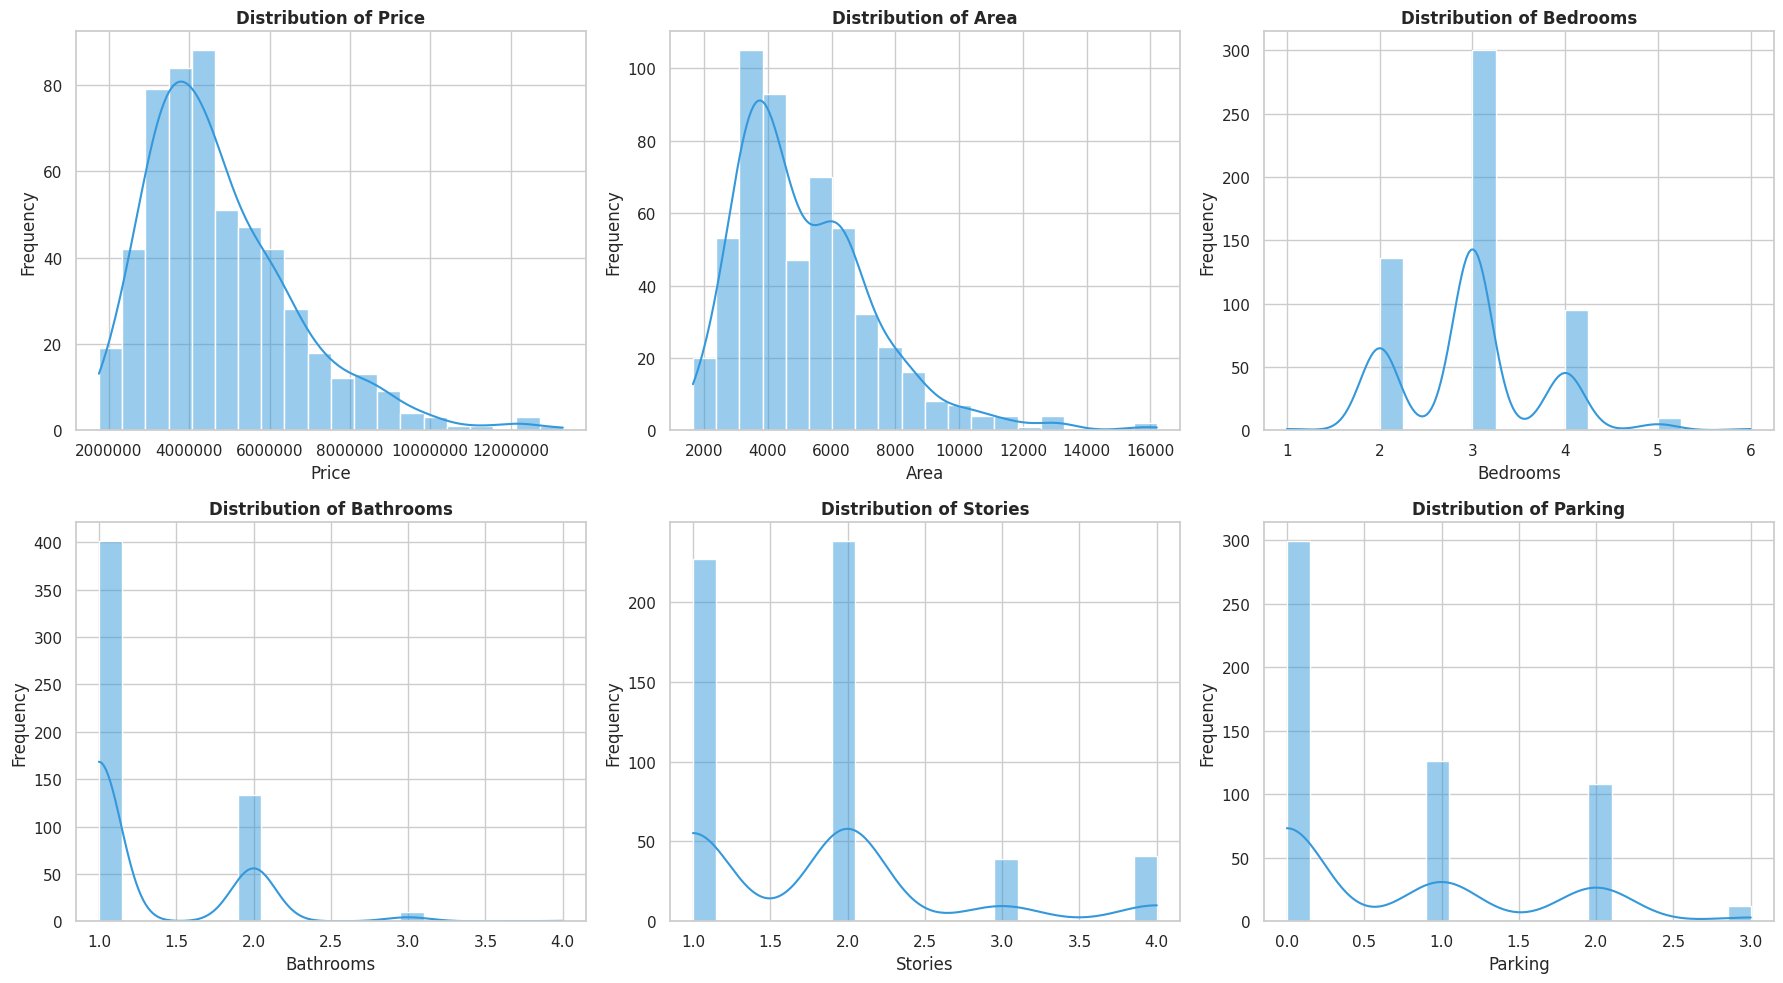


=== Tabular Data: Skewness Score ===
(Note: A score > 1 indicates a highly skewed/lopsided distribution)


,Skewness Score
bathrooms,1.59
area,1.32
price,1.21
stories,1.08
parking,0.84
bedrooms,0.50


In [ ]:
# EDA Part 1: Distribution of Numerical Variables and Skewness Analysis
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=20, ax=ax, color='#3498DB', kde=True)
    ax.set_title(f'Distribution of {col.capitalize()}', fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Frequency')

    # Forcing plain numbers (no scientific notation like 1e7, learned from module 7)
    if col in ['price', 'area']:
        ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

print("\n=== Tabular Data: Skewness Score ===")
print("(Note: A score > 1 indicates a highly skewed/lopsided distribution)")
skewness_table = df[num_cols].skew().to_frame(name='Skewness Score').sort_values('Skewness Score', ascending=False)
display(skewness_table.round(2))

**Insight Step 5 (Part 1): Distribution of Numerical Variables and Skewness Analysis**

* **Visual Observation:** The charts for `price` and `area` clearly show a "long tail" stretching to the right.

* **Tabular Proof:** The skewness table confirms this mathematically. Variables with a score > 1 (`bathrooms`, `area`, `price`, `stories`) are highly right-skewed (positive skew).

* **The Business Meaning:** This proves that the real estate market in this dataset is highly concentrated in the lower-to-middle tier. Most houses are smaller and more affordable, while a small minority of massive, premium luxury properties are pulling the average (and the tail of the chart) upward.

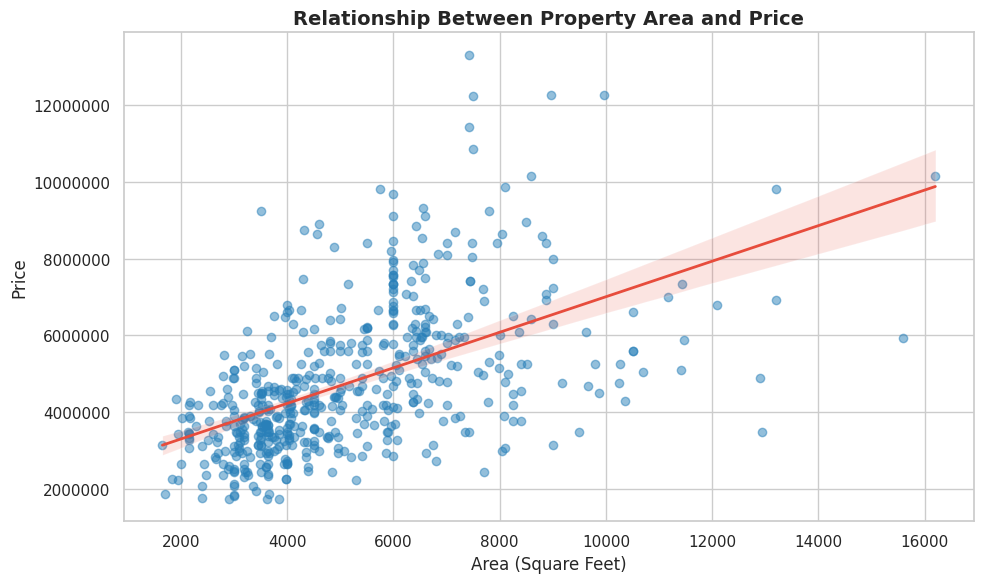


=== Tabular Data: Correlation Coefficient ===
Pearson Correlation between Area and Price: 0.5360


In [ ]:
# EDA Part 2: Continuous Relationship (Area vs Price)
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='area', y='price',
            scatter_kws={'alpha': 0.5, 'color': '#2980B9'},
            line_kws={'color': '#E74C3C', 'linewidth': 2})

plt.title('Relationship Between Property Area and Price', fontsize=14, fontweight='bold')
plt.xlabel('Area (Square Feet)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print("\n=== Tabular Data: Correlation Coefficient ===")
area_price_corr = df[['area', 'price']].corr().iloc[0, 1]
print(f"Pearson Correlation between Area and Price: {area_price_corr:.4f}")

**Insight Step 5 (Part 2): Continuous Variable Correlation (Area vs. Price)**

* **Visual Observation:** The regression plot demonstrates a clear positive linear trajectory between property area and market price. However, the wide dispersion of data points around the regression line indicates significant variance.

* **Tabular Proof:** The calculated Pearson Correlation Coefficient of 0.5360 statistically quantifies this relationship as a *moderate* positive correlation.

* **The Business Meaning:** While the physical footprint (area) is a primary driver of a property's valuation, the moderate correlation score proves it is not the sole determinant. The remaining statistical variance strongly implies that other categorical factors—such as amenities, condition, or location—exert a massive influence on the final market price.

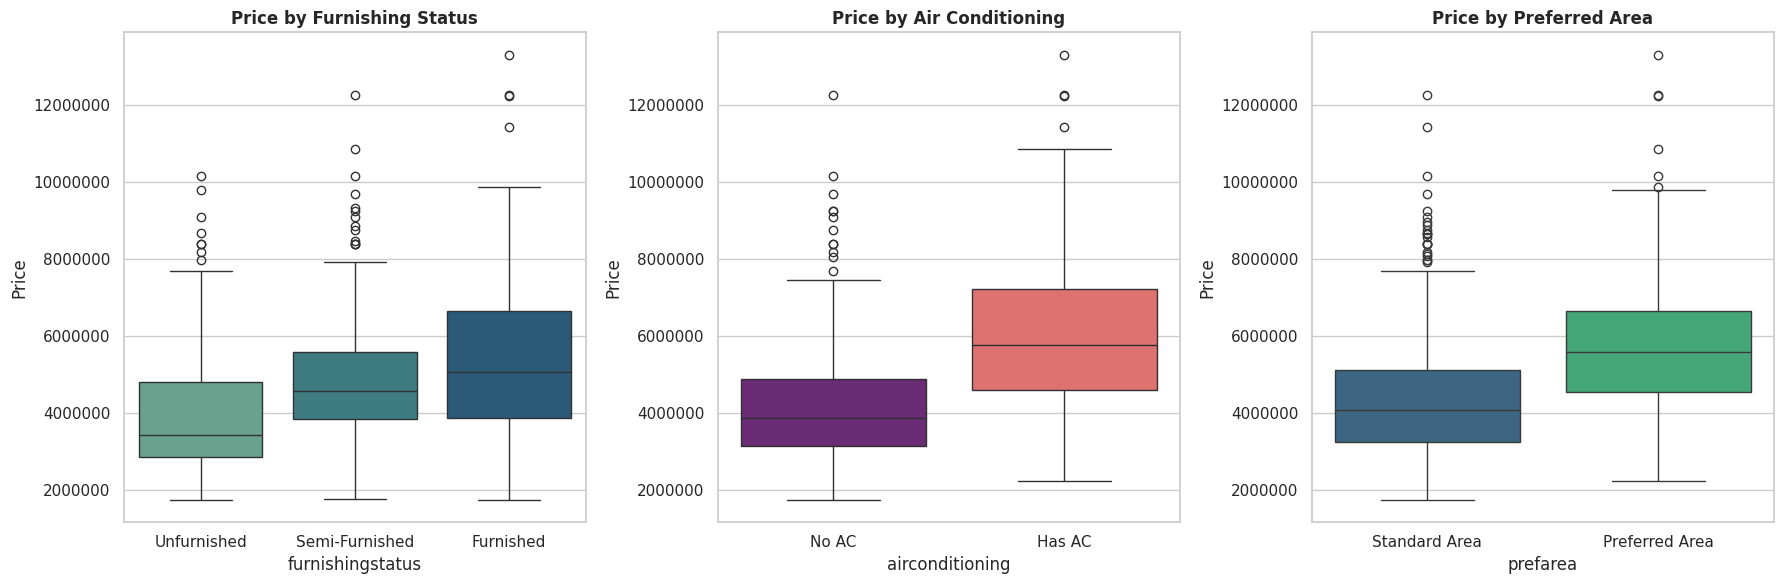


=== Tabular Data: Average Price by Premium Features ===


,No (0),Yes (1),Value Added Premium
Air Conditioning,4191940,6013221,1821281
Preferred Area,4425299,5879046,1453747
Guest Room,4544546,5792897,1248351


In [ ]:
# EDA Part 3: Categorical Impact on Housing Prices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot 1: Furnishing Status (0=Unfurnished, 1=Semi, 2=Furnished)
sns.boxplot(data=df, x='furnishingstatus', y='price', ax=axes[0], palette='crest')
axes[0].set_title('Price by Furnishing Status', fontweight='bold')
axes[0].set_xticklabels(['Unfurnished', 'Semi-Furnished', 'Furnished'])

# Boxplot 2: Air Conditioning (0=No, 1=Yes)
sns.boxplot(data=df, x='airconditioning', y='price', ax=axes[1], palette='magma')
axes[1].set_title('Price by Air Conditioning', fontweight='bold')
axes[1].set_xticklabels(['No AC', 'Has AC'])

# Boxplot 3: Preferred Area (0=No, 1=Yes)
sns.boxplot(data=df, x='prefarea', y='price', ax=axes[2], palette='viridis')
axes[2].set_title('Price by Preferred Area', fontweight='bold')
axes[2].set_xticklabels(['Standard Area', 'Preferred Area'])

for ax in axes:
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_ylabel('Price')

plt.tight_layout()
plt.show()

print("\n=== Tabular Data: Average Price by Premium Features ===")
categorical_summary = pd.DataFrame({
    'Air Conditioning': df.groupby('airconditioning')['price'].mean(),
    'Preferred Area': df.groupby('prefarea')['price'].mean(),
    'Guest Room': df.groupby('guestroom')['price'].mean()
}).T

categorical_summary.columns = ['No (0)', 'Yes (1)']

# Calculating the exact price (difference)
categorical_summary['Value Added Premium'] = categorical_summary['Yes (1)'] - categorical_summary['No (0)']
display(categorical_summary.round(0).astype(int))

**Insight Step 5 (Part 3): Categorical Value-Add and Price Premiums**

* **Visual Observation:** The boxplots clearly illustrate that categorical amenities drastically shift the price distribution upwards. Properties with air conditioning, premium locations (preferred area), and higher furnishing tiers exhibit distinctively higher median prices and elevated interquartile ranges.

* **Tabular Proof:** The mean price calculations reveal substantial "Value Added Premiums." Air conditioning acts as the strongest discrete market driver, adding an approximate premium of 1.82 million to the baseline valuation. Geographical location (Preferred Area) follows closely, commanding a ~1.45 million premium.

* **The Business Meaning:** Real estate valuation in this dataset is highly dependent on "comfort and location" multipliers. These premium features explain the variance observed in the baseline Area-to-Price regression; buyers are willing to pay aggressive market premiums for modernized amenities and geographical advantages, independent of the property's raw square footage.

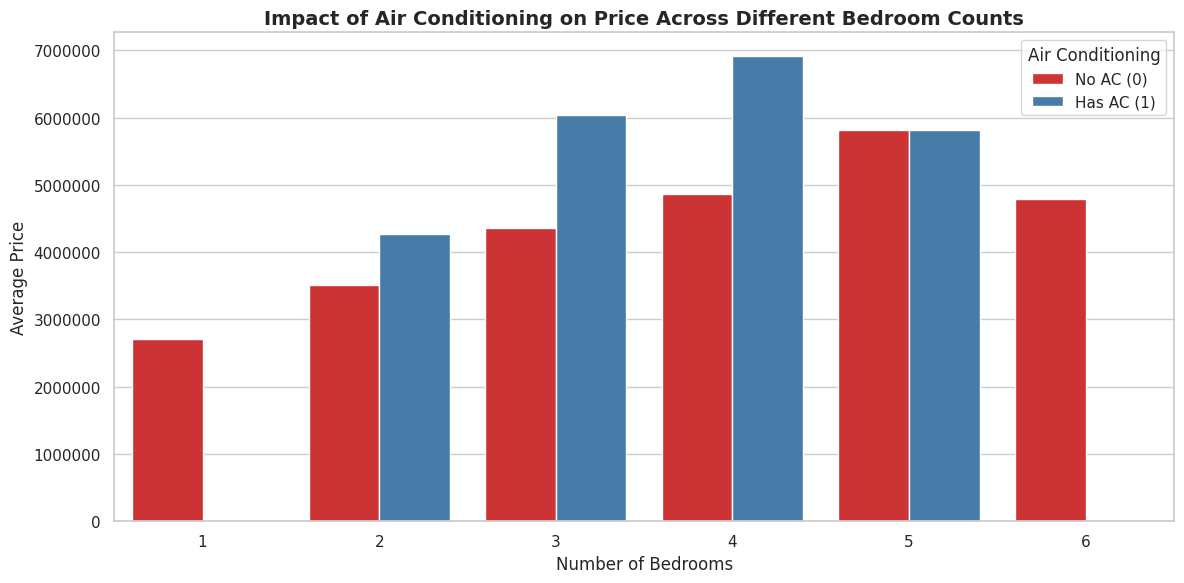


=== Tabular Data: Multivariate Price Averages ===


,No AC (0),Has AC (1),AC Value Premium
bedrooms,,,
1,2712500,0,0
2,3509088,4269045,759958
3,4353964,6037985,1684022
4,4863536,6920812,2057276
5,5820000,5819333,-667
6,4791500,0,0


In [ ]:
# EDA Part 4: Advanced Multivariate Analysis (The "Champion" Insight)
plt.figure(figsize=(12, 6))

# Visual Representation: Barplot combining 3 variables (Bedrooms, AC, and Price)
sns.barplot(data=df, x='bedrooms', y='price', hue='airconditioning', palette='Set1', errorbar=None)

plt.title('Impact of Air Conditioning on Price Across Different Bedroom Counts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.legend(title='Air Conditioning', labels=['No AC (0)', 'Has AC (1)'])

plt.tight_layout()
plt.show()


print("\n=== Tabular Data: Multivariate Price Averages ===")
multi_summary = df.groupby(['bedrooms', 'airconditioning'])['price'].mean().unstack()
multi_summary.columns = ['No AC (0)', 'Has AC (1)']

multi_summary['AC Value Premium'] = multi_summary['Has AC (1)'] - multi_summary['No AC (0)']

display(multi_summary.fillna(0).round(0).astype(int))

**Insight Step 5 (Part 4): Multivariate Interaction Effect (Bedrooms & AC vs. Price)**

* **Visual Observation:** The grouped bar chart illustrates a clear interaction effect between property size and climate control. The price delta (the gap between the bars) widens significantly as the bedroom count increases from 2 to 4.

* **Tabular Proof:** The calculated AC Value Premium proves that the financial impact of Air Conditioning scales non-linearly. It adds a ~760k premium to 2-bedroom properties, a ~1.68M premium to 3-bedroom properties, and peaks at a massive ~2.05M premium for 4-bedroom family homes. (The convergence at 5 bedrooms is statistically negligible due to sample size scarcity).

* **The Business Meaning:** Premium amenities act as price multipliers, not just flat additions. Buyers in the market for larger, 4-bedroom family estates view Air Conditioning as a non-negotiable luxury, whereas the premium is far less aggressive in the entry-level 2-bedroom market.

**6. Correlation Matrix**

> Buat correlation matrix, transformasi dulu seluruh data ke numerik agar tidak error saat masuk ke correlation matrix. Lalu berikan insight, apa yang kamu temukan dari correlation matrix dataset tersebut?

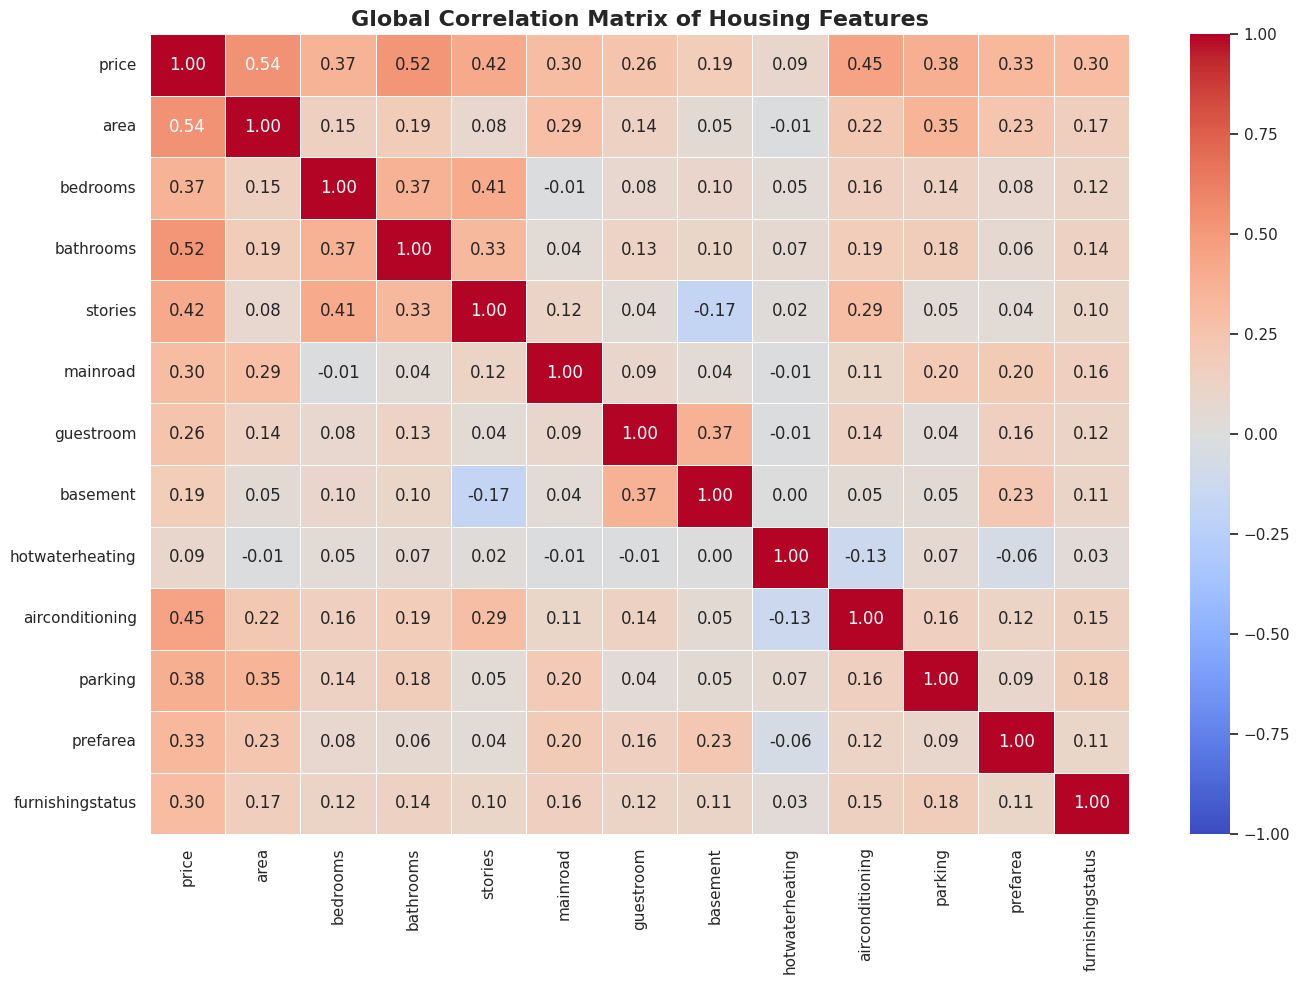


=== Tabular Data: Feature Correlation with Price ===
(Note: 1.0 is a perfect positive correlation, 0.0 is no correlation)


,Correlation with Price
price,1.000
area,0.536
bathrooms,0.518
airconditioning,0.453
stories,0.421
parking,0.384
bedrooms,0.366
prefarea,0.330
furnishingstatus,0.305
mainroad,0.297


In [ ]:
plt.figure(figsize=(14, 10))

corr_matrix = df.corr()

# Plot the heatmap (cmap='coolwarm' uses red for positive, blue for negative)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Global Correlation Matrix of Housing Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Tabular Data: Feature Correlation with Price ===")
print("(Note: 1.0 is a perfect positive correlation, 0.0 is no correlation)")

price_impact = corr_matrix[['price']].sort_values(by='price', ascending=False)

price_impact.columns = ['Correlation with Price']
display(price_impact.round(3))

**Insight Step 6: Global Correlation Matrix and Feature Dominance**

* **Primary Valuation Drivers:** The Pearson correlation matrix identifies `area` (0.536), `bathrooms` (0.518), and `airconditioning` (0.453) as the top three variables most positively correlated with `price`. This mathematically validates that raw square footage, sanitary privacy, and premium climate control are the primary valuation levers in this real estate market.

* **The Bedroom/Bathroom Anomaly:** Interestingly, the number of bathrooms (0.518) exhibits a significantly stronger correlation with price than the number of bedrooms (0.366). This suggests that modern market valuations prioritize luxury and convenience over mere sleeping capacity.

* **Low-Impact Features:** Variables such as `hotwaterheating` (0.093) and `basement` (0.187) show extremely weak linear correlations with the target variable, indicating they add negligible predictive power and may be candidates for elimination in a strict feature-selection modeling phase.

**7. Feature Engineering**



> Laksanakan Feature Engineering, buat variabel baru berdasarkan variabel yang sudah ada. Analisis hasil dari variabel baru tersebut.



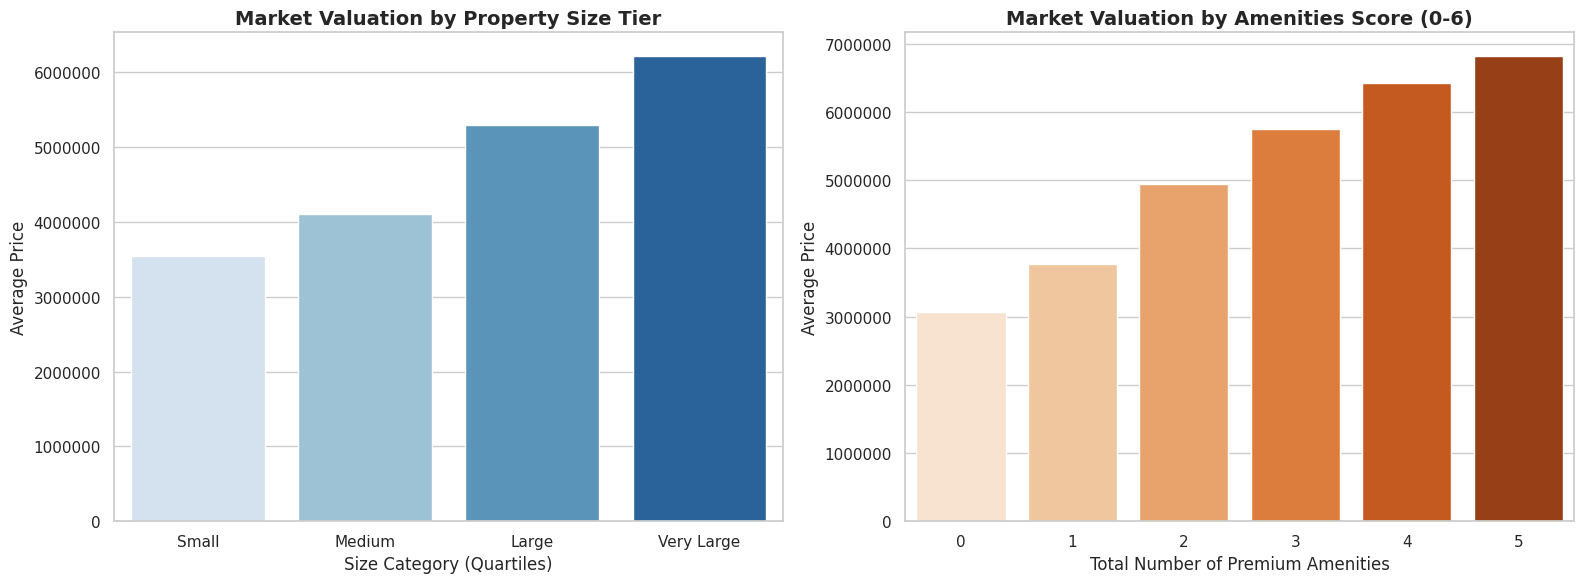


=== Feature Engineering: Correlation with Target Variable ===


,price
price,1.000
amenities_score,0.553
total_rooms,0.512
area_per_bedroom,0.245



=== Deep Dive: Valuation Multiplier by Amenities Score ===


,Number of Houses,Average Price
amenities_score,,
0,42,3072575
1,172,3768849
2,164,4944730
3,102,5743672
4,50,6428380
5,15,6824533


In [ ]:
# We create a copy to safely engineer new features
df_fe = df.copy()

df_fe['total_rooms'] = df_fe['bedrooms'] + df_fe['bathrooms']
df_fe['area_per_bedroom'] = df_fe['area'] / df_fe['bedrooms']

# 2. Amenities Score (Skor Fasilitas 0 - 6)
# Summing all 6 binary premium features
premium_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df_fe['amenities_score'] = df_fe[premium_cols].sum(axis=1)

# 3. Data Binning: Market Tier Categorization
# pd.qcut automatically divides the area into 4 mathematically equal percentiles (25% each)
df_fe['size_category'] = pd.qcut(df_fe['area'], q=4, labels=['Small', 'Medium', 'Large', 'Very Large'])

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average Price by Size Tier
sns.barplot(data=df_fe, x='size_category', y='price', ax=axes[0], palette='Blues', errorbar=None)
axes[0].set_title('Market Valuation by Property Size Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Size Category (Quartiles)', fontsize=12)
axes[0].set_ylabel('Average Price', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='y')

# Plot 2: Average Price by Amenities Score
sns.barplot(data=df_fe, x='amenities_score', y='price', ax=axes[1], palette='Oranges', errorbar=None)
axes[1].set_title('Market Valuation by Amenities Score (0-6)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Number of Premium Amenities', fontsize=12)
axes[1].set_ylabel('Average Price', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# --- TABULAR PROOF ---
print("\n=== Feature Engineering: Correlation with Target Variable ===")
new_features = ['price', 'amenities_score', 'total_rooms', 'area_per_bedroom']
feature_corr = df_fe[new_features].corr()[['price']].sort_values(by='price', ascending=False)
display(feature_corr.round(3))

print("\n=== Deep Dive: Valuation Multiplier by Amenities Score ===")
amenity_summary = df_fe.groupby('amenities_score')['price'].agg(['count', 'mean']).round(0).astype(int)
amenity_summary.columns = ['Number of Houses', 'Average Price']
display(amenity_summary)

# Update our main dataframe with these new features for any final steps
df = df_fe.copy()

**Insight Step 7: Advanced Feature Engineering and Predictive Synthesis**

* **The "Super Feature" Creation:** By aggregating multiple weaker binary variables, the newly engineered `amenities_score` successfully synthesized a holistic measure of property luxury. With a Pearson correlation coefficient of 0.553, it officially outperforms every original individual variable (including `area` and `bathrooms`) to become the strongest linear predictor of market price in the dataset.

* **Valuation Multipliers:** The deep-dive summary mathematically proves a compounding valuation multiplier. A property with zero premium amenities averages ~3.07M, while a property maximizing its amenities (score 5) commands an average of ~6.82M—more than double the baseline valuation.

* **Market Tiering (Quantile Binning):** Utilizing mathematical quartile binning to categorize raw area into a `size_category` reveals a strictly tiered pricing structure. The visual distribution proves that buyers do not just pay for linear square footage; they pay exponential premiums to cross the threshold into the "Very Large" market tier.

**8. Executive Summary & Final Conclusion**

Based on a comprehensive Exploratory Data Analysis (EDA) and Feature Engineering pipeline applied to the Housing Prices Dataset, the following key analytical conclusions are drawn:

1. **Optimal Data Integrity:** The initial structural audit revealed a highly sanitized dataset with exactly zero missing values (NaN) and zero duplicated records. Categorical variables were successfully encoded into a strictly numerical matrix, rendering the data fully optimized for future Machine Learning deployments.

2. **The Illusion of a Single Driver:** While raw property size (`area`) is historically assumed to be the sole driver of real estate valuation, the data proves otherwise. The relationship between area and price is only moderately positive (0.536), indicating significant valuation variance driven by other factors.

3. **The Power of Comfort & Infrastructure:** The correlation matrix and multivariate analyses definitively prove that modern buyers heavily prioritize infrastructure and comfort. Features like `airconditioning` and `bathrooms` act as exponential price multipliers, particularly in larger family homes (4+ bedrooms).

4. **The Ultimate Predictive Synthesis:** The most significant finding emerged during Feature Engineering. By aggregating individual amenities into a unified `amenities_score`, we created a holistic luxury metric that outperformed every original variable (Correlation: 0.553).

**Final Business Recommendation:** For predictive modeling (e.g., Linear Regression or Random Forest), the engineered features (`amenities_score`, `size_category`, and `total_rooms`) should be prioritized, while weak-impact variables (`hotwaterheating`, `basement`) should be considered for dimensionality reduction to prevent model noise.